# Bulk proteomics: QC → impute → differential expression

This tutorial walks through the **end-to-end `ov.protein` bulk label-free workflow** on a simulated MaxQuant-style dataset:

1. Load data (`simulate_lfq` here; `read_maxquant` / `read_diann` / `read_fragpipe` for real files)
2. QC filtering and missingness diagnostics
3. MCAR vs MNAR classification
4. Per-sample normalization
5. Missing-value imputation
6. Differential expression — comparing DEqMS / limma / proDA / Wilcoxon
7. Volcano plot and pathway enrichment

Every step is a single dispatcher with a `method=` argument. The statistical engines are the standalone R-parity packages `pyimputelcmd`, `pydeqms`, `pyproda`.

In [1]:
import omicverse as ov
import numpy as np
import matplotlib.pyplot as plt

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.0   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the data

For real experiments use a vendor reader — they all return an `AnnData` with `obs = samples`, `var = proteins`, raw intensities in `X`:

```python
adata = ov.protein.read_maxquant('proteinGroups.txt')      # MaxQuant
adata = ov.protein.read_diann('report.pg_matrix.tsv')      # DIA-NN
adata = ov.protein.read_fragpipe('combined_protein.tsv')   # FragPipe
```

Here we simulate a two-group label-free dataset with planted differential proteins, count-correlated variance, and MNAR dropouts.

In [2]:
adata = ov.protein.simulate_lfq(n_proteins=2000, n_per_group=6, seed=0)
print(adata)
print('overall missing fraction:', round(float(np.isnan(adata.X).mean()), 3))

AnnData object with n_obs × n_vars = 12 × 2000
    obs: 'group'
    var: 'Gene_names', 'is_de_true', 'peptides'
    uns: 'source'
overall missing fraction: 0.163


## 2. Quality control

`qc_filter` drops proteins with too few peptides or too many missing samples. `missing_pattern` / `missing_pattern_plot` summarize where the missingness sits — critical for choosing an imputer.

In [3]:
ov.protein.qc_filter(adata, min_peptides=2, min_valid=0.5)
stats = ov.protein.missing_pattern(adata)
print('after QC:', adata.shape, '| overall missing:', round(stats['overall'], 3))

after QC: (12, 1691) | overall missing: 0.083


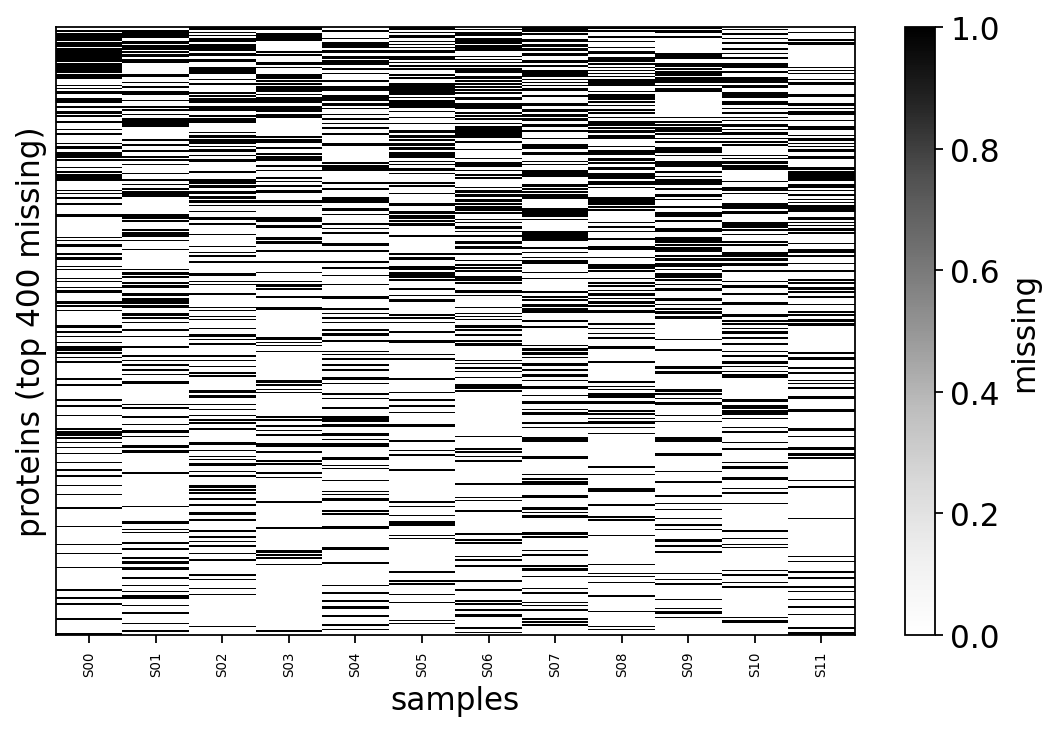

In [4]:
ov.protein.missing_pattern_plot(adata, max_proteins=400)
plt.show()

## 3. MCAR vs MNAR classification

`model_selector` (the imputeLCMD `model.Selector` algorithm) classifies each protein's missingness as **MCAR** (missing completely at random — use KNN/MLE) or **MNAR** (left-censored below the detection limit — use QRILC/MinProb). The flag is written to `adata.var['is_mcar']`.

In [5]:
mask, threshold = ov.protein.model_selector(adata)
print(f'MCAR proteins: {int(mask.sum())}  |  MNAR proteins: {int((~mask).sum())}')

MCAR proteins: 1689  |  MNAR proteins: 2


## 4. Normalization

`normalize` log2-transforms and centres each sample. `method='median'` is the standard LFQ default; `'equalize_medians'` (DEqMS-style), `'quantile'`, and `'log2'` (no centring — for already-normalised Olink NPX) are also available. The raw matrix is stashed in `adata.layers['raw']`.

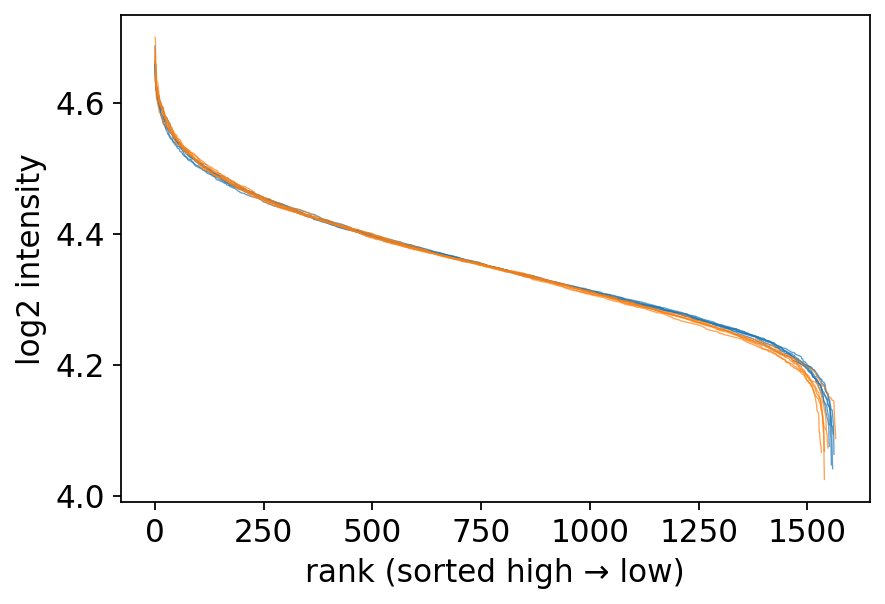

In [6]:
ov.protein.normalize(adata, method='median', log2=True)
ov.protein.abundance_rank_plot(adata, color_by='group')
plt.show()

## 5. Imputation

`impute` exposes the full imputeLCMD suite. For left-censored proteomics, `'qrilc'` (quantile-regression truncated normal) is the recommended default. `'auto'` runs `model_selector` and routes MCAR proteins to KNN and MNAR proteins to QRILC.

In [7]:
ov.protein.impute(adata, method='qrilc', seed=0)
print('missing values remaining:', int(np.isnan(adata.X).sum()))

missing values remaining: 0


## 6. Differential expression

`de` dispatches to six engines. **DEqMS** borrows strength across proteins with similar peptide counts — the recommended choice when a peptide-count column is available.

In [8]:
res = ov.protein.de(adata, group='group', method='deqms', count_var='peptides')
res.head()

,gene,logFC,AveExpr,count,t,P.Value,adj.P.Val
0,prot_1735,-1.875689,18.771184,12.0,-5.136928,0.000014,0.009902
1,prot_0358,1.667829,21.889090,21.0,5.050770,0.000018,0.009902
2,prot_0690,1.928043,19.443895,9.0,4.969322,0.000023,0.009902
3,prot_0864,-1.683827,19.922716,15.0,-4.962857,0.000023,0.009902
4,prot_1382,-1.935163,20.067655,12.0,-4.880846,0.000030,0.010027


How well does each method recover the planted differential proteins? We score the top-N (N = number of true DE proteins) against the ground truth.

In [9]:
true_de = set(adata.var.index[adata.var['is_de_true']])
n_true = len(true_de)

for m in ['deqms', 'limma', 'proda', 'wilcoxon']:
    r = ov.protein.de(adata, group='group', method=m, count_var='peptides')
    recall = len(set(r['gene'].head(n_true)) & true_de) / n_true
    print(f'{m:10s} top-{n_true} recall = {recall:.1%}')

deqms      top-216 recall = 70.4%
limma      top-216 recall = 69.9%


proda      top-216 recall = 69.0%


wilcoxon   top-216 recall = 64.4%


## 7. Volcano plot

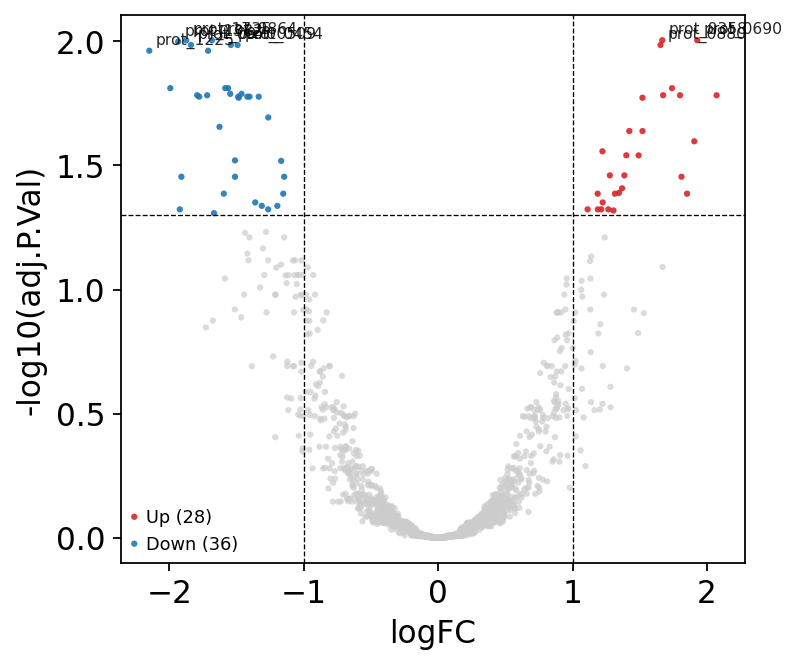

In [10]:
ov.protein.volcano(res, fc_col='logFC', p_col='adj.P.Val',
                   logfc_threshold=1.0, adj_p_threshold=0.05)
plt.show()

## 8. Pathway enrichment

`enrich` forwards a DE result table (ranked by the `t` statistic) to the `ov.es` enrichment kernels. Pass any signature dict; here a toy gene set illustrates the call.

In [11]:
signatures = {
    'planted_DE': list(true_de)[:50],
    'random_set': list(adata.var_names[:50]),
}
enr = ov.protein.enrich(res, signatures=signatures, method='ora')
enr

(          planted_DE  random_set
 de_query    3.287898    7.084733,
             planted_DE  random_set
 de_query  2.237960e-27         0.0)

## Summary

| Stage | Function | Key methods |
|---|---|---|
| Load | `read_maxquant` / `read_diann` / `read_fragpipe` / `simulate_lfq` | — |
| QC | `qc_filter`, `missing_pattern` | — |
| Missingness | `model_selector` | MCAR / MNAR |
| Normalize | `normalize` | median, equalize_medians, quantile, log2 |
| Impute | `impute` | qrilc, mindet, minprob, mle, knn, svd, auto |
| DE | `de` | deqms, limma, proda, wilcoxon, welch_t, anova, kruskal |
| Enrich | `enrich` | ora, gsea, ulm, aucell, … |
| Plot | `volcano`, `missing_pattern_plot`, `abundance_rank_plot` | — |

For peptide-level input see [Peptide → protein summarization](t_protein_02_summarization.ipynb); for Olink see [Olink NPX analysis](t_protein_03_olink.ipynb).